In [1]:
### Import libraries ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import kendalltau
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import json
import copy
import optuna
import os

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
try:
    from google.colab import drive, files
    drive.mount('/content/drive')
    folder_path = '/content/drive/MyDrive/my_data_folder/'
except ImportError:
    folder_path = "./processed_data"

In [4]:
TUNING_DIR = "nn_output/tuning"
os.makedirs(TUNING_DIR, exist_ok=True)

X_train_path = os.path.join(folder_path, 'X_train.csv')
X_test_path = os.path.join(folder_path, 'X_test.csv')
X_val_path = os.path.join(folder_path, 'X_val.csv')
y_train_path = os.path.join(folder_path, 'y_train.csv')
y_test_path = os.path.join(folder_path, 'y_test.csv')
y_val_path = os.path.join(folder_path, 'y_val.csv')

E1_train_path = os.path.join(folder_path, 'E1_train.npy')
E2_train_path = os.path.join(folder_path, 'E2_train.npy')
E1_test_path = os.path.join(folder_path, 'E1_test.npy')
E2_test_path = os.path.join(folder_path, 'E2_test.npy')
E1_val_path = os.path.join(folder_path, 'E1_val.npy')
E2_val_path = os.path.join(folder_path, 'E2_val.npy')

print(f"Data paths set. Checking if files exist...")
all_file_paths = [
    X_train_path, X_test_path, X_val_path,
    y_train_path, y_test_path, y_val_path,
    E1_train_path, E2_train_path, E1_test_path,
    E2_test_path, E1_val_path, E2_val_path
]
for f in all_file_paths:
    print(f"{f}: {'Found' if os.path.exists(f) else 'Not Found'}")

Data paths set. Checking if files exist...
./processed_data\X_train.csv: Found
./processed_data\X_test.csv: Found
./processed_data\X_val.csv: Found
./processed_data\y_train.csv: Found
./processed_data\y_test.csv: Found
./processed_data\y_val.csv: Found
./processed_data\E1_train.npy: Found
./processed_data\E2_train.npy: Found
./processed_data\E1_test.npy: Found
./processed_data\E2_test.npy: Found
./processed_data\E1_val.npy: Found
./processed_data\E2_val.npy: Found


In [5]:
SEED = 101
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
g = torch.Generator()
g.manual_seed(101)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
TARGET_VARIABLE = "Mole fraction"

In [6]:
# X_train = pd.read_csv("X_train.csv")
# X_test = pd.read_csv("X_test.csv")
# X_val = pd.read_csv("X_val.csv")
# y_train = pd.read_csv("y_train.csv")
# y_test = pd.read_csv("y_test.csv")
# y_val = pd.read_csv("y_val.csv")

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
X_val = pd.read_csv(X_val_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)
y_val = pd.read_csv(y_val_path)

In [7]:
X_train.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)
X_test.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)
X_val.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True
)

In [8]:
def separate_features(X):
    return X.iloc[:, 0:3], X.iloc[:, 3:203], X.iloc[:, 203:403],  X.iloc[:, 403:428], X.iloc[:, 428:]
# property_T_P, Component 1 Descriptors, Component 2 Descriptors, Property category, phase

In [9]:
X_train_prop, X_train_comp1_desc, X_train_comp2_desc, X_train_prop_cat, X_train_phase = separate_features(X_train)
X_test_prop, X_test_comp1_desc, X_test_comp2_desc, X_test_prop_cat, X_test_phase = separate_features(X_test)
X_val_prop, X_val_comp1_desc, X_val_comp2_desc, X_val_prop_cat, X_val_phase = separate_features(X_val)

In [10]:
def make_symmetric(comp1, comp2):
    X1 = np.array(comp1)
    X2 = np.array(comp2)
    prod = pd.DataFrame(X1 * X2, columns=[f'prod_{i}' for i in range(X1.shape[1])])
    summ = pd.DataFrame(X1 + X2, columns=[f'sum_{i}'  for i in range(X1.shape[1])])
    return pd.concat([prod, summ], axis=1)

X_train_symmetric = make_symmetric(X_train_comp1_desc, X_train_comp2_desc)
X_val_symmetric   = make_symmetric(X_val_comp1_desc,   X_val_comp2_desc)
X_test_symmetric  = make_symmetric(X_test_comp1_desc,  X_test_comp2_desc)

# Reconstruct full feature matrix
def reconstruct(prop, symmetric, prop_cat, phase):
    dfs = [prop, symmetric, prop_cat, phase]
    for df in dfs:
        df.reset_index(drop=True, inplace=True)
    return pd.concat(dfs, axis=1)

X_train = reconstruct(X_train_prop, X_train_symmetric, X_train_prop_cat, X_train_phase)
X_val   = reconstruct(X_val_prop,   X_val_symmetric,   X_val_prop_cat,   X_val_phase)
X_test  = reconstruct(X_test_prop,  X_test_symmetric,  X_test_prop_cat,  X_test_phase)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

def to_loader(X, y, batch_size=1024, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32).squeeze().unsqueeze(1)
    )
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        generator=g if shuffle else None,
        worker_init_fn=lambda worker_id: np.random.seed(101 + worker_id) if shuffle else None
    )

train_loader = to_loader(X_train_scaled, y_train, shuffle=True)
val_loader   = to_loader(X_val_scaled, y_val)

In [13]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
            nn.Hardtanh(min_val=0.0, max_val=1.0)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def objective(trial):
    lr         = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    dropout    = trial.suggest_float('dropout', 0.1, 0.4)
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])

    model = MLPRegressor(X_train.shape[1], dropout=dropout,
                         hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    fast_train_loader = to_loader(X_train_scaled, y_train, batch_size=2048, shuffle=True)
    fast_val_loader   = to_loader(X_val_scaled,   y_val,   batch_size=2048)

    for epoch in range(50):
        model.train()
        for X_batch, y_batch in fast_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = np.mean([
                criterion(model(X_b.to(device)), y_b.to(device)).item()
                for X_b, y_b in fast_val_loader
            ])
        scheduler.step(val_loss)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
)
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Best params:", study.best_params)
print("Best val MSE:", study.best_value)

[I 2026-04-09 14:08:30,708] A new study created in memory with name: no-name-de7a5914-4dce-4737-98d8-809e315b4c9c
  0%|          | 0/30 [00:00<?, ?it/s]

In [28]:
# Training loop

best_params = study.best_params
model = MLPRegressor(X_train.shape[1],
                     hidden_dim=best_params['hidden_dim'],
                     dropout=best_params['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_loss = float('inf')
best_model_state = None
train_loss_history = []
val_loss_history = []

n_epochs = 300
for epoch in range(n_epochs):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_losses = [
            criterion(model(X_b.to(device)), y_b.to(device)).item()
            for X_b, y_b in val_loader
        ]
    val_loss = np.mean(val_losses)
    scheduler.step(np.mean(val_losses))
    # Save best weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
    # Add at bottom of the epoch loop:
    train_loss_history.append(np.mean(train_losses))
    val_loss_history.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} — Train MSE: {np.mean(train_losses):.4f} — Val MSE: {val_loss:.4f}")


Epoch 10/300 — Train MSE: 0.0520 — Val MSE: 0.0492
Epoch 20/300 — Train MSE: 0.0403 — Val MSE: 0.0368
Epoch 30/300 — Train MSE: 0.0351 — Val MSE: 0.0321
Epoch 40/300 — Train MSE: 0.0315 — Val MSE: 0.0281
Epoch 50/300 — Train MSE: 0.0302 — Val MSE: 0.0273
Epoch 60/300 — Train MSE: 0.0292 — Val MSE: 0.0269
Epoch 70/300 — Train MSE: 0.0284 — Val MSE: 0.0257
Epoch 80/300 — Train MSE: 0.0280 — Val MSE: 0.0249
Epoch 90/300 — Train MSE: 0.0270 — Val MSE: 0.0242
Epoch 100/300 — Train MSE: 0.0257 — Val MSE: 0.0220
Epoch 110/300 — Train MSE: 0.0253 — Val MSE: 0.0230
Epoch 120/300 — Train MSE: 0.0251 — Val MSE: 0.0226
Epoch 130/300 — Train MSE: 0.0241 — Val MSE: 0.0207
Epoch 140/300 — Train MSE: 0.0240 — Val MSE: 0.0213
Epoch 150/300 — Train MSE: 0.0237 — Val MSE: 0.0207
Epoch 160/300 — Train MSE: 0.0239 — Val MSE: 0.0209
Epoch 170/300 — Train MSE: 0.0237 — Val MSE: 0.0206
Epoch 180/300 — Train MSE: 0.0237 — Val MSE: 0.0210
Epoch 190/300 — Train MSE: 0.0244 — Val MSE: 0.0218
Epoch 200/300 — Train

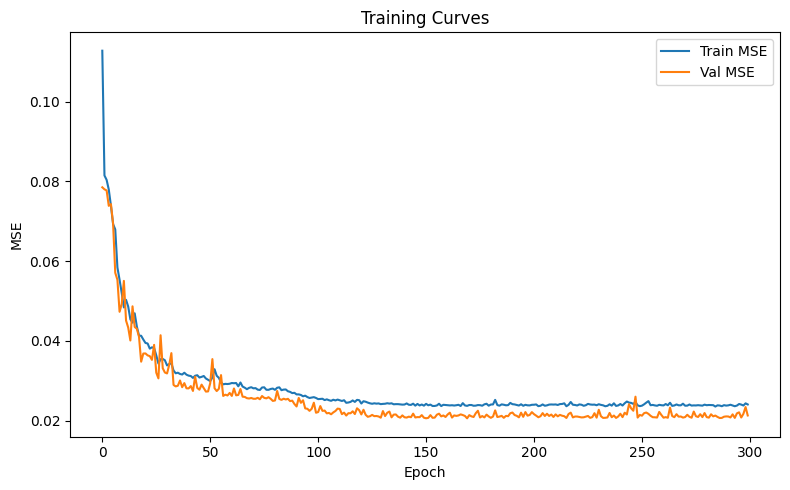

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Train MSE')
plt.plot(val_loss_history, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves_mlp.png', dpi=150)
plt.show()

In [ ]:
torch.save({
    "model_state_dict": best_model_state,
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_loss": best_val_loss,
    "input_dim":  X_train.shape[1],
    "hidden_dim": best_params["hidden_dim"],
    "dropout":    best_params["dropout"],
}, "mlp_baseline.pth")
print("Checkpoint saved to mlp_baseline.pth")

In [18]:
def evaluate_model(y_test, y_pred, show_plot=False, save_file=False, save_path="./results.json"):
    """Evaluate model performance given true and predicted values."""
    y_test = np.array(y_test).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    tau = kendalltau(y_test, y_pred).correlation

    # Bootstrap CI
    rng = np.random.default_rng(101)
    mae_scores, mse_scores, r2_scores, tau_scores = [], [], [], []

    for _ in range(1000):
        idx = rng.integers(0, len(y_test), len(y_test))
        mae_scores.append(mean_absolute_error(y_test[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_test[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_test[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_test[idx], y_pred[idx]).correlation)

    mae_std = np.std(mae_scores)
    mse_std = np.std(mse_scores)
    r2_std  = np.std(r2_scores)
    tau_std = np.std(tau_scores)

    mae_ci  = np.percentile(mae_scores, [2.5, 97.5])
    mse_ci  = np.percentile(mse_scores, [2.5, 97.5])
    r2_ci   = np.percentile(r2_scores,  [2.5, 97.5])
    tau_ci  = np.percentile(tau_scores, [2.5, 97.5])

    print(f"MAE          = {mae:.4f}, Std: {mae_std:.4f} (95% CI: {mae_ci[0]:.4f}–{mae_ci[1]:.4f})")
    print(f"MSE          = {mse:.4f}, Std: {mse_std:.4f} (95% CI: {mse_ci[0]:.4f}–{mse_ci[1]:.4f})")
    print(f"R²           = {r2:.4f}, Std: {r2_std:.4f} (95% CI: {r2_ci[0]:.4f}–{r2_ci[1]:.4f})")
    print(f"Kendall's τ  = {tau:.4f}, Std: {tau_std:.4f} (95% CI: {tau_ci[0]:.4f}–{tau_ci[1]:.4f})")

    if save_file:
        results = {"MAE": mae, "MSE": mse, "R2": r2, "Kendall_tau": tau}
        with open(save_path, "w") as f:
            json.dump(results, f)
        print(f"Results saved to {save_path}")

    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.1, s=10)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect fit")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Actual vs Predicted")
        plt.legend()
        plt.show()

In [27]:
# Load model from checkpoint
checkpoint = torch.load("mlp_baseline.pth", map_location=device, weights_only=False)
print(checkpoint.keys())
model_params = checkpoint["model_state_dict"]
print(model_params.keys())
model = MLPRegressor(
    input_dim=checkpoint["input_dim"],
    hidden_dim=model_params["hidden_dim"],
    dropout=checkpoint["dropout"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded MLP | input_dim={checkpoint["input_dim"]}, "
      f"hidden_dim={checkpoint["hidden_dim"]}, dropout={checkpoint["dropout"]}, "
      f"best_val_loss={checkpoint["best_val_loss"]:.4f}")

dict_keys(['model_state_dict', 'optimizer_state_dict', 'best_val_loss', 'input_dim'])
odict_keys(['net.0.weight', 'net.0.bias', 'net.1.weight', 'net.1.bias', 'net.1.running_mean', 'net.1.running_var', 'net.1.num_batches_tracked', 'net.4.weight', 'net.4.bias', 'net.5.weight', 'net.5.bias', 'net.5.running_mean', 'net.5.running_var', 'net.5.num_batches_tracked', 'net.8.weight', 'net.8.bias', 'net.9.weight', 'net.9.bias', 'net.9.running_mean', 'net.9.running_var', 'net.9.num_batches_tracked', 'net.12.weight', 'net.12.bias'])


KeyError: 'hidden_dim'

In [17]:
# Restore best weights
model = MLPRegressor()
model.load_state_dict(best_model_state)

# Predict
model.eval()
with torch.no_grad():
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_pred_val = model(X_val_tensor).cpu().numpy().flatten()
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    y_pred_test = model(X_test_tensor).cpu().numpy().flatten()

# Evaluate
evaluate_model(y_test, y_pred_test, show_plot=True)
evaluate_model(y_val, y_pred_val, show_plot=True)

TypeError: MLPRegressor.__init__() missing 1 required positional argument: 'input_dim'

In [36]:
history_df = pd.DataFrame({
    'Epoch': range(1, len(train_loss_history) + 1),
    'Train MSE': train_loss_history,
    'Val MSE': val_loss_history
})

history_df.to_csv('training_loss_history_baseline.csv', index=False)
print("Training loss history saved to training_loss_history_baseline.csv")

# Also copy this file to Google Drive
shutil.copy('training_loss_history_baseline.csv', os.path.join(folder_path, 'training_loss_history_baseline.csv'))
print(f"Saved training_loss_histor_baseline.csv to {folder_path}")

Training loss history saved to training_loss_history_baseline.csv
Saved training_loss_histor_baseline.csv to /content/drive/MyDrive/my_data_folder/


In [34]:
import shutil

# List of files to save
files_to_save = ["mlp_baseline.pth", "training_curves_mlp.png"]

# Copy each file to your specified Google Drive folder
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(folder_path, f))
        print(f"Saved {f} to {folder_path}")
    else:
        print(f"File {f} not found in local storage.")

Saved mlp_baseline.pth to /content/drive/MyDrive/my_data_folder/
Saved training_curves_mlp.png to /content/drive/MyDrive/my_data_folder/
